# Synthetic data vizualisation


In [3]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import scienceplots


def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in (start, *start.parents):
        if (p / 'pyproject.toml').exists():
            return p
    return start


REPO_ROOT = _find_repo_root(Path.cwd())
for p in (REPO_ROOT, REPO_ROOT / 'src'):
    ps = str(p)
    if ps not in sys.path:
        sys.path.append(ps)

from active_wasserstein.data.synthetic_branching import OscillatorySequentialBranching

plt.style.use(['science'])
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.grid'] = False

FIGURES_DIR = REPO_ROOT / 'figures'
FIG_PATH = FIGURES_DIR / 'oscillatory_sequential_branching_2d.pdf'

SEED = 42
N_PARTICLES = 1200
SUBSAMPLE = 8
BRANCH_MARKER_OFFSET = 0.02

TRAJECTORY_KWARGS = {
    't_start': 0.0,
    't_end': 1.0,
    'dt': 0.005,
    'kappa': 20.0,
    'sigma_diff': 0.2,
    'init_sigma': 0.05,
    'obs_dim': 10,
    'latent_dim': 2,
    'obs_noise': 0.0,
    'branch_scale': 2.0,
    'event1': (0.30, 0.35),
    'event2': (0.70, 0.75),
    'split_branch_sign': -1,
    'nuisance_freq': 30.0,
    'nuisance_amp': 0.5,
    'q_seed': SEED,
}


In [4]:
def nearest_index(t: float, grid: np.ndarray) -> int:
    return int(np.argmin(np.abs(grid - t)))


traj = OscillatorySequentialBranching(**TRAJECTORY_KWARGS)
rng = np.random.default_rng(SEED)
sim = traj.simulate(n=N_PARTICLES, rng=rng, return_latent=True, return_fates=False)

times = sim['times']
latent = sim['latent']

rot = np.array([[0.0, -1.0], [1.0, 0.0]])
latent_rot = latent @ rot.T

(event1_start, event1_end) = traj.event1
(event2_start, event2_end) = traj.event2


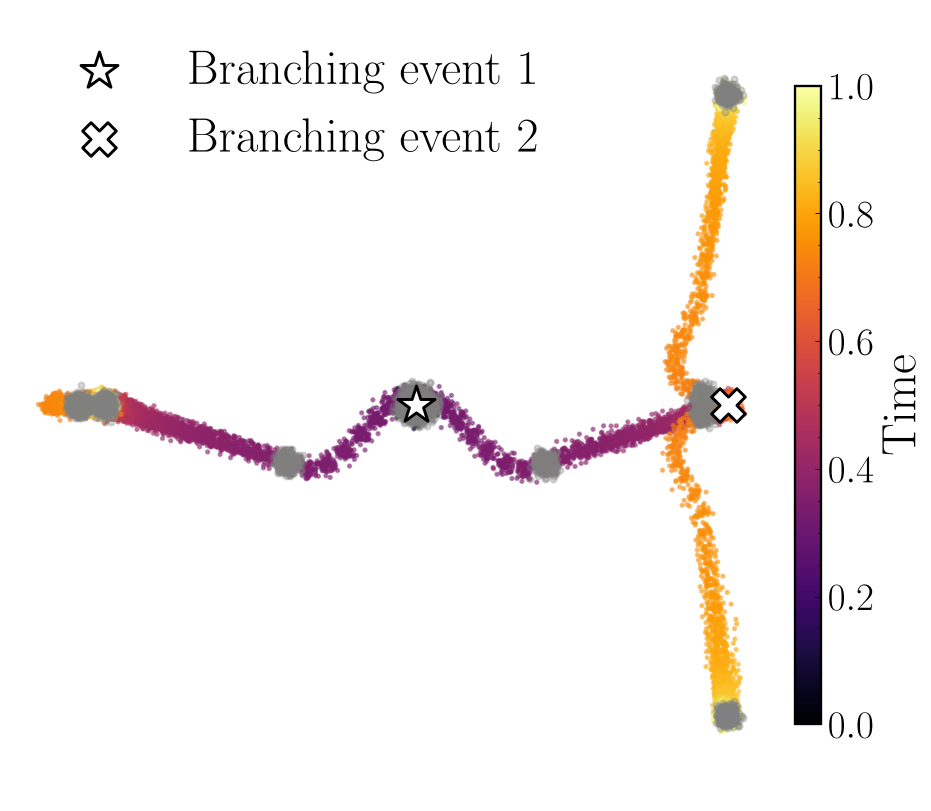

In [5]:
points = latent_rot.reshape(-1, 2)
time_colors = np.repeat(times, latent.shape[1])

points_sub = points[::SUBSAMPLE]
time_colors_sub = time_colors[::SUBSAMPLE]
mean_path = latent_rot.mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    points_sub[:, 0],
    points_sub[:, 1],
    c=time_colors_sub,
    s=3,
    alpha=0.5,
    cmap='inferno',
    rasterized=True,
)

n_slices = 4
diffs = np.diff(mean_path, axis=0)
segment_lengths = np.linalg.norm(diffs, axis=1)
arc_length = np.concatenate([[0], np.cumsum(segment_lengths)])
total_length = arc_length[-1]
target_lengths = np.linspace(0, total_length, n_slices)
slice_indices = [np.argmin(np.abs(arc_length - s)) for s in target_lengths]

for idx in slice_indices:
    ax.scatter(
        latent_rot[idx, :, 0],
        latent_rot[idx, :, 1],
        s=10,
        color='grey',
        alpha=0.3,
        zorder=8,
        rasterized=True,
    )

idx1 = nearest_index(event1_start - BRANCH_MARKER_OFFSET, times)
idx2 = nearest_index(event2_start - BRANCH_MARKER_OFFSET, times)
idx_mid = nearest_index(0.5 * (event1_end + event2_start), times)
splitting_branch_mask = latent_rot[idx_mid, :, 0] > 0

mu1 = latent_rot[idx1].mean(axis=0)
mu2 = latent_rot[idx2][splitting_branch_mask].mean(axis=0)

ax.scatter(
    mu1[0],
    mu1[1],
    marker='*',
    s=400,
    color='white',
    edgecolors='black',
    linewidths=1.5,
    label='Branching event 1',
    zorder=10,
)
ax.scatter(
    mu2[0],
    mu2[1],
    marker='X',
    s=300,
    color='white',
    edgecolors='black',
    linewidths=1.5,
    label='Branching event 2',
    zorder=10,
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])
ax.axis('equal')

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    loc='upper left',
    fontsize=25,
    framealpha=0.9,
    edgecolor='none',
)
for text in legend.get_texts():
    text.set_path_effects([pe.withStroke(linewidth=2, foreground='white')])

cbar = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.8, aspect=25)
cbar.set_label('Time', color='black', fontsize=25, fontweight='bold')
cbar.ax.yaxis.label.set_path_effects([pe.withStroke(linewidth=2, foreground='white')])
cbar.ax.tick_params(colors='black', labelsize=20)
for tick in cbar.ax.get_yticklabels():
    tick.set_path_effects([pe.withStroke(linewidth=2, foreground='white')])
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1.2)
cbar.solids.set_alpha(1.0)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_PATH, bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()
